# 11: Additional Baselines (DRUNet-alone and FBPConvNet)

This notebook develops two further baselines to strengthen the NB10 comparison, both discussed in Meeting 04 with Ander and Andrea.

## Significance

1. DRUNet-alone applies denoising directly to FBP, providing an insight to what the denoiser would do without the ADMM loop. It helps place a baselie upon why the PnP algorithm is useful.
2. FBPConvNet is a supervised U-Net mapping FBP to ground truth, and is a purely data-driven baseline with no algorithmic prior, that is trained on the same 250-image / 80-epoch budget as TFPnP run_04 for a fair comparison.

After development, both baselines are added to NB10 as additional method columns in the main results table and bar charts.

## 1. Setup

In [ ]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

import ct_tfpnp
from ct_tfpnp.ct_ops.fbp import fbp as lion_fbp
from ct_tfpnp.ct_ops.admm import ADMMStep
from ct_tfpnp.models.denoiser import DRUNetDenoiser
from ct_tfpnp.evaluation.metrics import psnr_np as psnr, ls_scale, evaluate_reconstruction
from ct_tfpnp.datasets.lidc import get_lion_split, is_lung_slice
from ct_tfpnp.experiments.parallel_beam_ct import experiment
from ct_tfpnp.utils import to_4d, setup_admm
from LION.CTtools.ct_utils import make_operator

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"ct_tfpnp : {ct_tfpnp.__version__}")
print(f"device   : {device}")

ct_tfpnp : 0.1.dev13+gf0142ec56.d20260617
device   : cuda


Using the imports above we now create the geometry required and prepare adequate data

In [ ]:
# Geometry, operator, denoiser, ADMM step — single helper now
DENOISER_PATH = Path("/home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth")

geo, op, denoiser, admm_step = setup_admm(DENOISER_PATH, device)
print(f"  Geometry: {geo.image_shape}, {len(geo.angles)} angles")

# Load one test image to develop against (the dev-loop pattern from NB05)
test_images, test_indices = get_lion_split(split="test", geometry=geo, device=device)
print(f"  Test set: {len(test_images)} images")

# Pick a lung slice for the figure (matches NB05's dev image conventions)
lung_indices = [i for i, img in enumerate(test_images) if is_lung_slice(img)]
DEV_IDX = lung_indices[len(lung_indices) // 2] if lung_indices else 0
gt = test_images[DEV_IDX]
print(f"  Dev image: test_{test_indices[DEV_IDX]} (slice {DEV_IDX})")

# set consistent plotting style for all notebook cells
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "image.cmap": "gray",
    "image.interpolation": "nearest",
})

# create output directory for figures
output_dir = Path("../figures/11")
output_dir.mkdir(parents=True, exist_ok=True)

Loaded DRUNet weights from /home/eaz21/rds/hpc-work/eaz21/results/baselines/drunet_gray.pth
  Geometry: [  1 512 512], 30 angles
Preparing patient list, this may take time....
Patient lists ready for test dataset
LION test split: 389 images, range [0.0000, 2.2075]
  Test set: 389 images
  Dev image: test_189 (slice 189)


Finally, a noisy sinogram is generated, along with its FBP reconstruction.

In [ ]:
NOISE_STD = 0.05

sino_clean = op.forward(gt)
SCALE = sino_clean.max() / gt.max()
torch.manual_seed(99)
sino_scaled = sino_clean / SCALE
noise = NOISE_STD * sino_scaled.std() * torch.randn_like(sino_scaled)
y = (sino_scaled + noise) * SCALE
gt_np = gt[0].cpu().numpy()
vmin, vmax = gt_np.min(), gt_np.max()

x_fbp = lion_fbp(y, op)
x_fbp = ls_scale(gt, x_fbp).clamp(min=0)
print(f"  FBP PSNR @ {NOISE_STD*100:.0f}% noise: {psnr(gt, x_fbp):.2f} dB")

  FBP PSNR @ 5% noise: 15.20 dB


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


## 2. DRUNet-alone

### Motivation

DRUNet sits inside PnP-ADMM as the denoising step, and the Fixed PnP-ADMM baseline runs it 20 times (with `n_x_steps=6` data-fidelity gradient steps between each). TFPnP runs it variably with σ scheduled by the policy.

A natural question arises of what does DRUNet do on its own? 

If a single forward pass through DRUNet on the FBP reconstructs the image well, the whole PnP-ADMM iterative framing is doing little work, which makes TFPnP's contribution questionable.


### Implementation

DRUNet takes an image and a noise level. For one-shot denoising, it is applied to the FBP at a chosen σ.

In [ ]:
def drunet_alone(fbp, sigma, denoiser=denoiser):
    """One forward pass through DRUNet on an FBP reconstruction.

    Args:
        fbp: tensor (1, H, W) — FBP reconstruction
        sigma: float — denoising strength
        denoiser: DRUNetDenoiser instance

    Returns:
        denoised: tensor (1, H, W)
    """
    with torch.no_grad():
        denoised = denoiser(to_4d(fbp), sigma)
    return denoised.squeeze(0)

### σ sensitivity

DRUNet has one free parameter, so a sweep over a small range of $\sigma$ is carried out to see whether 1.5 is reasonable or if a different value would be more competitive when the denoiser is on its own.

     σ |  PSNR (dB)
----------------------
   1.0 |      15.27
   1.5 |      15.37
   2.5 |      15.78
   5.0 |      18.04
   7.5 |      20.83
  10.0 |      21.83
  15.0 |      21.52


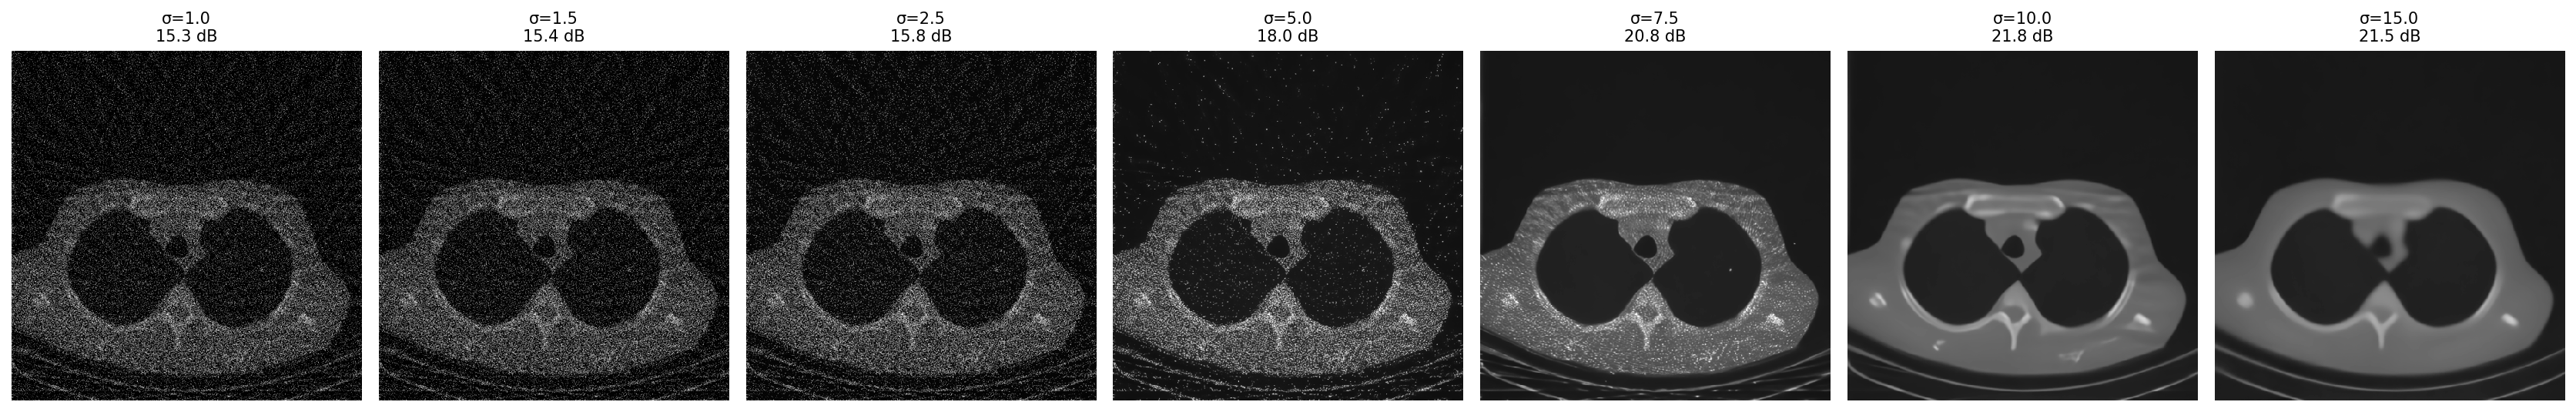

In [ ]:
# σ sweep on the same dev image
sigma_grid = [1.0, 1.5, 2.5, 5.0, 7.5, 10.0, 15.0]
results = []

for s in sigma_grid:
    x_s = drunet_alone(x_fbp, sigma=s)
    x_s = ls_scale(gt, x_s).clamp(min=0)
    results.append((s, psnr(gt, x_s), x_s))

# Print table
print(f"{'σ':>6} | {'PSNR (dB)':>10}")
print("-" * 22)
for s, p, _ in results:
    print(f"{s:>6.1f} | {p:>10.2f}")

# Plot all of them
fig, axes = plt.subplots(1, len(sigma_grid), figsize=(3.2 * len(sigma_grid), 3.5))
for ax, (s, p, x_s) in zip(axes, results):
    ax.imshow(x_s[0].cpu().numpy(), vmin=vmin, vmax=vmax, cmap='gray')
    ax.set_title(f"σ={s}\n{p:.1f} dB", fontsize=10)
    ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / "02_sigma_sweep.pdf", bbox_inches="tight")
plt.show()

The sweep shows the optimal σ for one-shot DRUNet denoising of FBP is σ≈10, about 7× the σ used inside Fixed PnP-ADMM (σ=1.5). 

Inside PnP-ADMM, the denoiser operates on the current iterate x, which after a few iterations has had its corruption reduced by the data-fidelity term. By the time the denoiser is called, the image really does look mildly noisy, so σ=1.5 is correct. But the raw FBP is heavily corrupted by streak artifacts, and one-shot denoising needs a much larger σ to match the actual corruption level.

This is empirical evidence that the iterative coupling in PnP-ADMM is doing meaningful work, as it progressively reduces corruption to the point where conservative denoising becomes appropriate. We discuss this further in the report's Methods chapter.

We use σ=10 (the sweep optimum on this dev image) for the canonical DRUNet-alone baseline going forward.

### Visual check at optimal $\sigma$

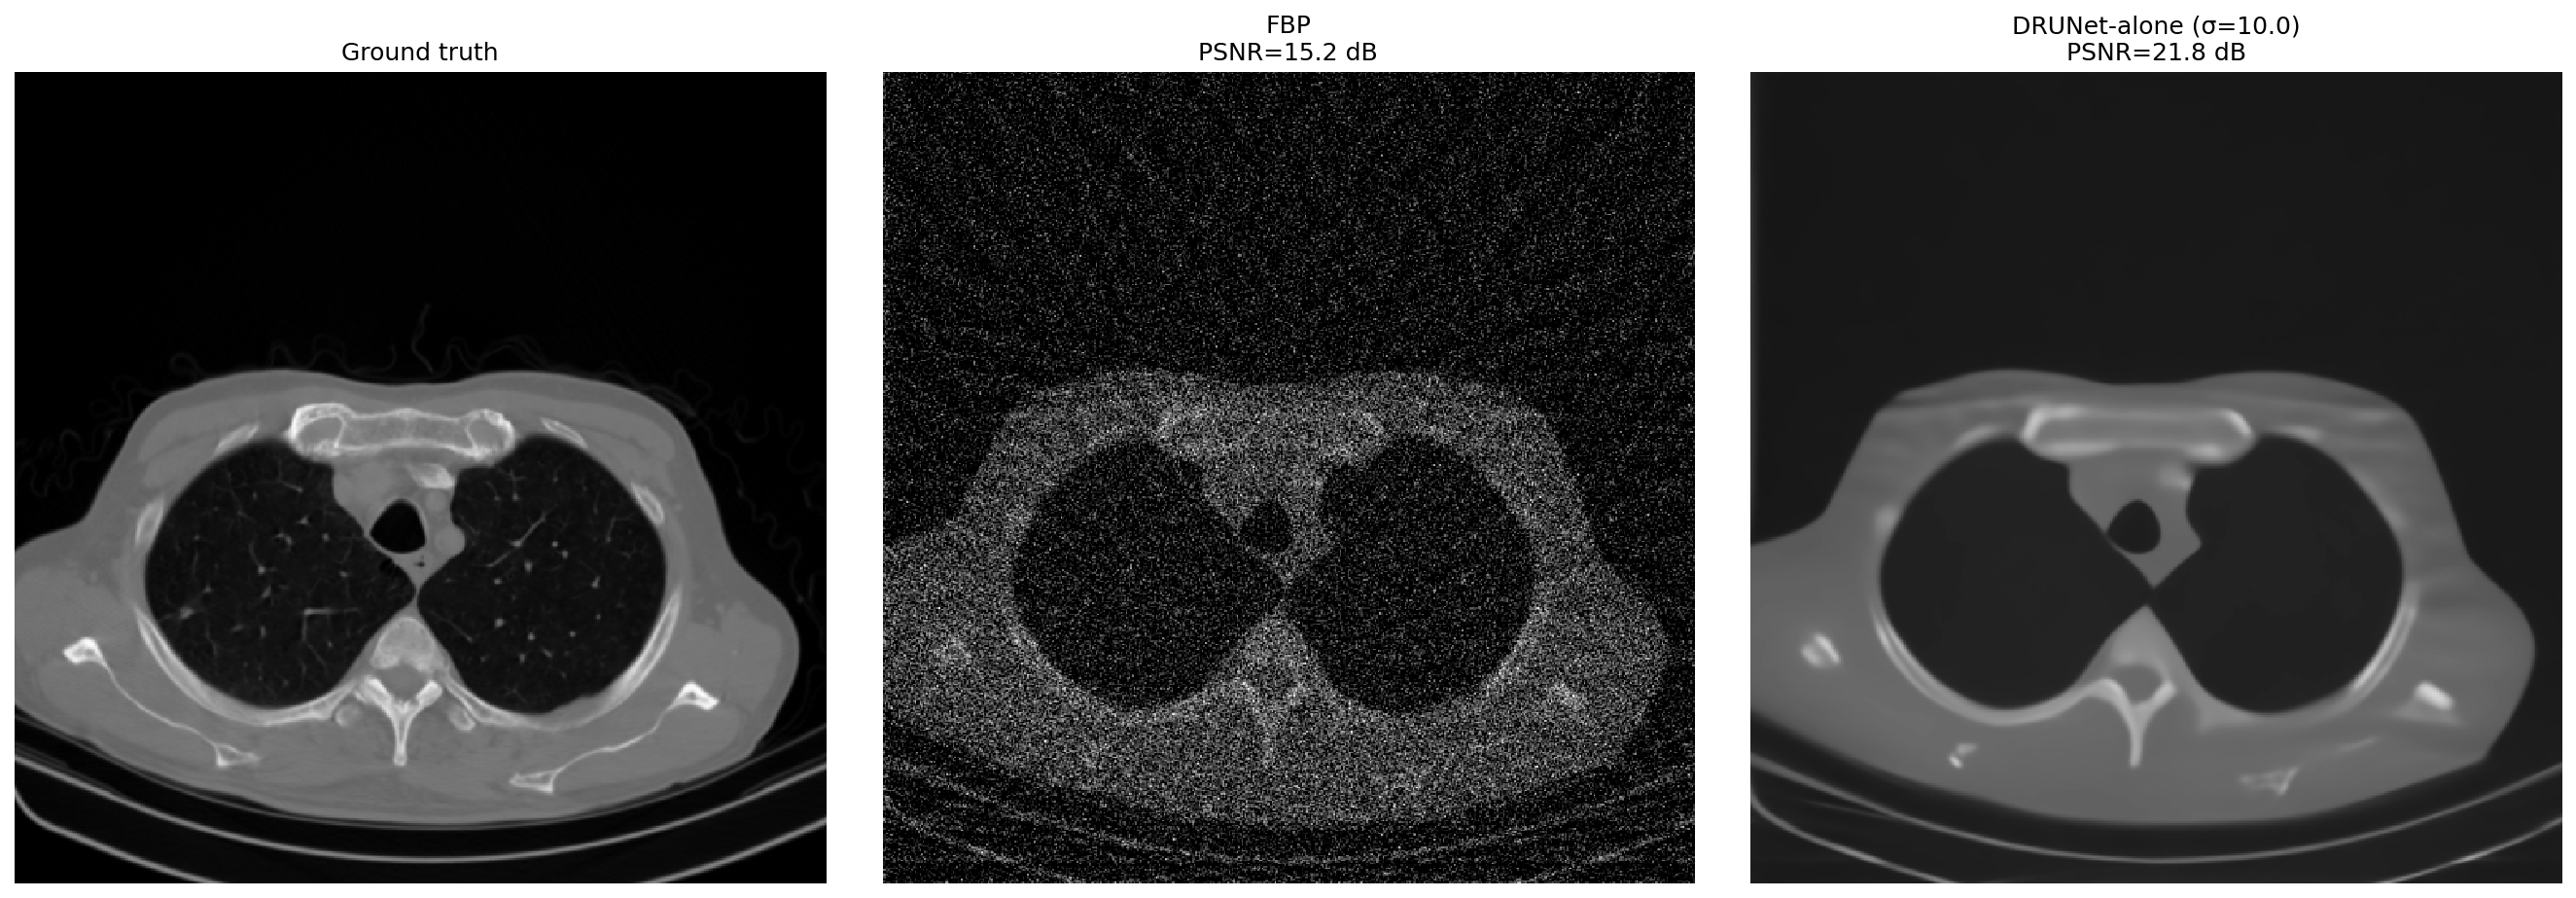


Improvement over FBP: +6.63 dB


In [ ]:
# Apply DRUNet at the sweep-optimal σ
DRUNET_ALONE_SIGMA = 10.0

x_drunet = drunet_alone(x_fbp, sigma=DRUNET_ALONE_SIGMA)
x_drunet = ls_scale(gt, x_drunet).clamp(min=0)

fbp_psnr = psnr(gt, x_fbp)
drunet_psnr = psnr(gt, x_drunet)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, img, title in zip(
    axes,
    [gt_np, x_fbp[0].cpu().numpy(), x_drunet[0].cpu().numpy()],
    ["Ground truth", f"FBP\nPSNR={fbp_psnr:.1f} dB",
     f"DRUNet-alone (σ={DRUNET_ALONE_SIGMA})\nPSNR={drunet_psnr:.1f} dB"]):
    ax.imshow(img, vmin=vmin, vmax=vmax, cmap='gray')
    ax.set_title(title, fontsize=12)
    ax.axis('off')

plt.tight_layout()
plt.savefig(output_dir / "01_DRUNet_alone_development.pdf", bbox_inches="tight")
plt.show()

print(f"\nImprovement over FBP: {drunet_psnr - fbp_psnr:+.2f} dB")

### Comparison: DRUNet-alone vs Fixed PnP-ADMM

The whole point of this baseline is to see what one denoising pass buys
relative to the iterative version. Fixed PnP-ADMM uses the same denoiser
20 times at the same σ.

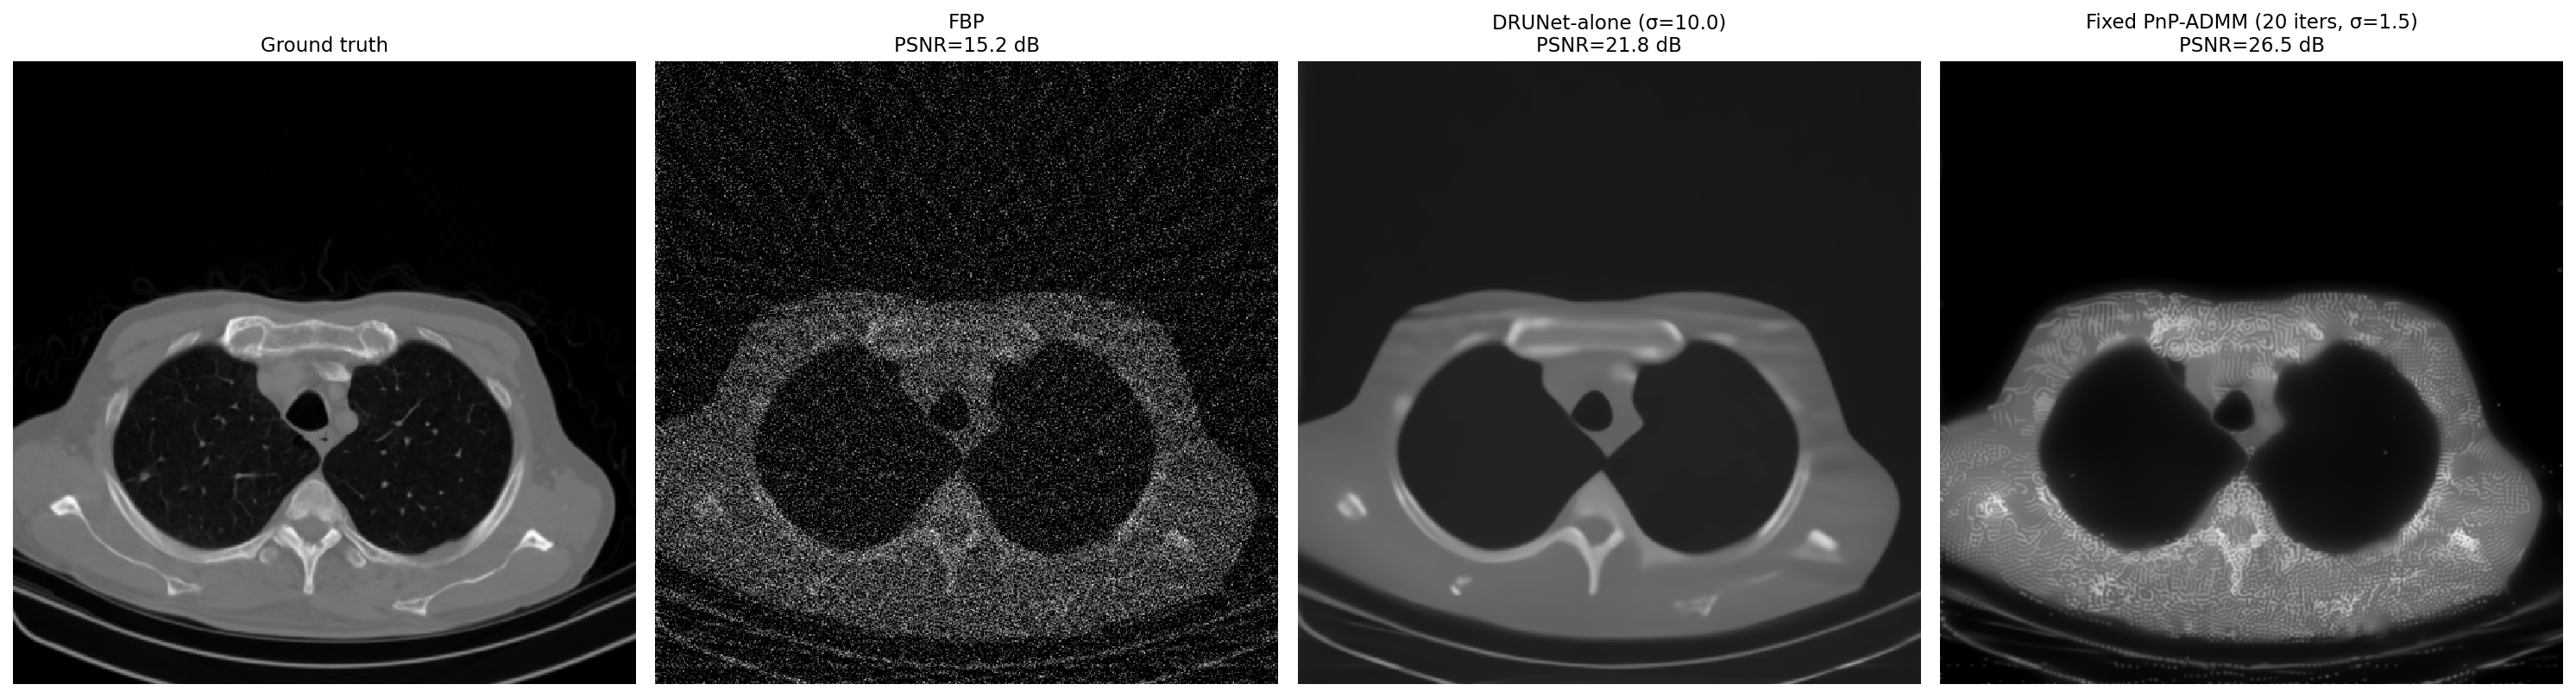


Gap (Fixed PnP-ADMM vs DRUNet-alone): +4.69 dB


In [ ]:
# Run Fixed PnP-ADMM at σ=1.5, μ=20
FIXED_SIGMA, FIXED_MU = 1.5, 20.0

x, z, u = x_fbp.clone(), x_fbp.clone(), torch.zeros_like(x_fbp)
with torch.no_grad():
    for k in range(20):
        x, z, u = admm_step(x, z, u, y, sigma=FIXED_SIGMA, mu=FIXED_MU)
x_fix = ls_scale(gt, x).clamp(min=0)
fix_psnr = psnr(gt, x_fix)

# 4-panel: GT / FBP / DRUNet-alone / Fixed PnP-ADMM
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
panels = [
    (gt_np, "Ground truth"),
    (x_fbp[0].cpu().numpy(), f"FBP\nPSNR={fbp_psnr:.1f} dB"),
    (x_drunet[0].cpu().numpy(),
     f"DRUNet-alone (σ={DRUNET_ALONE_SIGMA})\nPSNR={drunet_psnr:.1f} dB"),
    (x_fix[0].cpu().numpy(),
     f"Fixed PnP-ADMM (20 iters, σ=1.5)\nPSNR={fix_psnr:.1f} dB"),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, vmin=vmin, vmax=vmax, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
plt.tight_layout()
plt.savefig(output_dir / "03_fixed_comparison.pdf", bbox_inches="tight")
plt.show()

print(f"\nGap (Fixed PnP-ADMM vs DRUNet-alone): "
      f"{fix_psnr - drunet_psnr:+.2f} dB")

### Moving to the package

Nothing new to move — `DRUNetDenoiser` is already in `ct_tfpnp.models.denoiser`.
The `drunet_alone()` function above is so trivial it doesn't need to live in
the package; we'll inline it directly into `evaluate_run.py` as a new method
branch, alongside FBP / TV / Fixed PnP / TFPnP.

In `run_evaluation()`:

```python
# DRUNet-alone (σ chosen empirically — see NB11 §2)
DRUNET_ALONE_SIGMA = 10.0
x_drunet = drunet_alone(x_fbp, sigma=DRUNET_ALONE_SIGMA, denoiser=denoiser)
x_drunet = ls_scale(gt, x_drunet).clamp(min=0)
all_results[noise_frac]['DRUNet'].append(compute_metrics(gt, x_drunet))
```

And add `'DRUNet'` to the `METHODS` list and a colour to the palette.

## 3. FBPConvNet

### Motivation

Jin, McCann, Froustey & Unser (2017), *"Deep Convolutional Neural Network
for Inverse Problems in Imaging"*. A U-Net trained to map FBP → ground truth
on paired CT data. Purely data-driven — no algorithmic prior, no iteration.

This is the canonical learned post-processing baseline for sparse-view CT,
and is included in the original TFPnP paper's comparison table. We match
the TFPnP run_04 budget (250 training images, 80 epochs) so the comparison
is apples-to-apples: same data, same compute, two different approaches.

### Verify LION's FBPConvNet

In [ ]:
from LION.models.post_processing.FBPConvNet import FBPConvNet

class FBPConvNetImage(FBPConvNet):
    """FBPConvNet variant that takes a pre-computed FBP image directly.

    The parent class's forward() calls LION's `fdk()` internally to convert
    the sinogram input to an FBP image, but that function only supports
    cone-beam geometries. For parallel-beam (or any other geometry),
    pre-compute the FBP yourself with an appropriate reconstruction routine
    and pass it directly to this subclass.

    All other behaviour (architecture, residual connection from FBP, parameters)
    is inherited unchanged from FBPConvNet.
    """

    def forward(self, image):
        # Input is already an FBP image; skip the parent's `fdk(x, self.op)` step.
        block_1_res = self.block_1_down(image)
        block_2_res = self.block_2_down(self.down_1(block_1_res))
        block_3_res = self.block_3_down(self.down_2(block_2_res))
        block_4_res = self.block_4_down(self.down_3(block_3_res))

        res = self.block_bottom(self.down_4(block_4_res))
        res = self.block_1_up(torch.cat((block_4_res, self.up_1(res)), dim=1))
        res = self.block_2_up(torch.cat((block_3_res, self.up_2(res)), dim=1))
        res = self.block_3_up(torch.cat((block_2_res, self.up_3(res)), dim=1))
        res = self.block_4_up(torch.cat((block_1_res, self.up_4(res)), dim=1))
        res = self.block_last(res)

        # Residual connection: U-Net predicts a correction to the FBP
        return image + res

# Instantiate the subclass with FBPConvNet's default parameters
model_params = FBPConvNet.default_parameters()
fbpconv = FBPConvNetImage(model_parameters=model_params, geometry_parameters=geo).to(device)
n_params = sum(p.numel() for p in fbpconv.parameters())
print(f"FBPConvNetImage: {n_params/1e6:.2f}M parameters")

# Quick forward pass — now takes an FBP image directly, no internal FDK
with torch.no_grad():
    out = fbpconv(to_4d(x_fbp))
print(f"Input shape  (FBP image): {to_4d(x_fbp).shape}")
print(f"Output shape:             {out.shape}")

FBPConvNetImage: 34.56M parameters
Input shape  (FBP image): torch.Size([1, 1, 512, 512])
Output shape:             torch.Size([1, 1, 512, 512])


### Training data setup

LION's `SupervisedSolver` expects paired training data. We mirror the
TFPnP run_04 split exactly: same 250 train images, same val set.

In [13]:
from torch.utils.data import DataLoader, TensorDataset

# Same split as TFPnP run_01 (matching the small-scale local dev)
train_images, _ = get_lion_split("train", geometry=geo, device="cpu")
val_images, _ = get_lion_split("validation", geometry=geo, device="cpu")

N_TRAIN = 20
N_VAL = 10
train_images = train_images[:N_TRAIN]
val_images = val_images[:N_VAL]
print(f"Train: {len(train_images)}, Val: {len(val_images)}")

# Build a placeholder dataset; sinograms/FBPs are generated on-the-fly in the training loop
gt_stack = torch.stack(train_images)
dummy_sino = torch.zeros(len(train_images), 1, 1, 1)
train_ds = TensorDataset(dummy_sino, gt_stack)
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True)
print(f"Train loader: {len(train_loader)} batches of size 4")

Preparing patient list, this may take time....
Patient lists ready for train dataset
LION train split: 3300 images, range [0.0000, 2.4475]
Preparing patient list, this may take time....
Patient lists ready for validation dataset
LION validation split: 401 images, range [0.0000, 2.3958]
Train: 20, Val: 10
Train loader: 5 batches of size 4


### Smoke test (1 epoch on 5 images)

Verify the training pipeline runs end-to-end before committing to the full
80-epoch run. Mirrors the smoke-test pattern from NB09.

In [ ]:
import math

# Tiny subset for smoke
train_loader_smoke = DataLoader(
    TensorDataset(torch.zeros(5, 1, 1, 1), torch.stack(train_images[:5])),
    batch_size=1, shuffle=True)

optimizer_smoke = torch.optim.Adam(fbpconv.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

print("Smoke test: 1 epoch on 5 images")
fbpconv.train()
for batch_idx, (_, gt_batch) in enumerate(train_loader_smoke):
    gt_batch = gt_batch.to(device)

    # Generate sinogram + FBP on-the-fly
    with torch.no_grad():
        sino_b = op.forward(gt_batch[0])
        scale_b = sino_b.max() / gt_batch[0].max()
        sino_n = sino_b / scale_b + 0.05 * (sino_b / scale_b).std() * torch.randn_like(sino_b)
        y_b = sino_n * scale_b
        fbp_b = lion_fbp(y_b, op).unsqueeze(0)

    optimizer_smoke.zero_grad()
    out = fbpconv(fbp_b)
    loss = loss_fn(out, gt_batch)
    loss.backward()
    optimizer_smoke.step()
    print(f"  batch {batch_idx}: loss={loss.item():.6f}")

print("✓ Smoke test passed — pipeline runs end-to-end")

Smoke test: 1 epoch on 5 images


/rds/user/eaz21/hpc-work/projects/tomosipo/tomosipo/links/torch.py:63: UserWarning: The parameter initial_value should be contiguous. It has been automatically made contiguous. Use `ts.link(x.contiguous())' to inhibit this warning. 
  warnings.warn(


  batch 0: loss=0.245500
  batch 1: loss=0.219172
  batch 2: loss=0.179946
  batch 3: loss=0.143767
  batch 4: loss=0.136062
✓ Smoke test passed — pipeline runs end-to-end


### Full training (250 images × 80 epochs)

Mirrors TFPnP run_04 budget. On an A100 this takes ~30 min.

Re-initialise the model so we don't continue from the smoke-test weights.

In [ ]:
# Fresh model for the actual training run (separate from smoke-test weights)
fbpconv = FBPConvNetImage(model_parameters=model_params, geometry_parameters=geo).to(device)
optimizer = torch.optim.Adam(fbpconv.parameters(), lr=1e-4)

N_EPOCHS = 20
SAVE_DIR = Path("/home/eaz21/rds/hpc-work/eaz21/results/learned/fbpconvnet_pat_20_e20")
SAVE_DIR.mkdir(parents=True, exist_ok=True)

train_losses, val_psnrs = [], []
best_val = -float('inf')

for epoch in range(1, N_EPOCHS + 1):
    fbpconv.train()
    epoch_loss = 0.0
    for _, gt_batch in train_loader:
        gt_batch = gt_batch.to(device)

        with torch.no_grad():
            # On-the-fly sinogram + noise + FBP for each batch
            fbp_b_list = []
            for g in gt_batch:
                sino_b = op.forward(g)
                scale_b = sino_b.max() / g.max()
                noise_b = 0.05 * (sino_b / scale_b).std() * torch.randn_like(sino_b)
                y_b = (sino_b / scale_b + noise_b) * scale_b
                fbp_b_list.append(lion_fbp(y_b, op))
            fbp_b = torch.stack(fbp_b_list)

        optimizer.zero_grad()
        out = fbpconv(fbp_b)
        loss = loss_fn(out, gt_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)

    # Validation
    fbpconv.eval()
    val_psnr_sum = 0.0
    with torch.no_grad():
        for v_gt in val_images:
            v_gt = v_gt.to(device)
            sino_v = op.forward(v_gt)
            scale_v = sino_v.max() / v_gt.max()
            torch.manual_seed(42)  # fixed val noise
            noise_v = 0.05 * (sino_v / scale_v).std() * torch.randn_like(sino_v)
            y_v = (sino_v / scale_v + noise_v) * scale_v
            fbp_v = lion_fbp(y_v, op)
            out_v = fbpconv(to_4d(fbp_v))
            val_psnr_sum += psnr(v_gt, ls_scale(v_gt, out_v[0]).clamp(min=0))
    avg_val = val_psnr_sum / len(val_images)
    val_psnrs.append(avg_val)

    if avg_val > best_val:
        best_val = avg_val
        torch.save({'epoch': epoch,
                    'model_state_dict': fbpconv.state_dict(),
                    'val_psnr': avg_val},
                   SAVE_DIR / "checkpoint_best_val.pth")

    print(f"Epoch {epoch:>3}/{N_EPOCHS}: loss={avg_loss:.6f} | val PSNR={avg_val:.2f} dB"
          + ("  (new best)" if avg_val == best_val else ""))

print(f"\nDone. Best val PSNR: {best_val:.2f} dB → saved to {SAVE_DIR}")

Epoch   1/20: loss=0.252396 | val PSNR=14.34 dB  (new best)
Epoch   2/20: loss=0.111982 | val PSNR=14.37 dB  (new best)
Epoch   3/20: loss=0.063359 | val PSNR=14.60 dB  (new best)
Epoch   4/20: loss=0.036473 | val PSNR=15.33 dB  (new best)
Epoch   5/20: loss=0.031057 | val PSNR=16.96 dB  (new best)
Epoch   6/20: loss=0.027455 | val PSNR=19.69 dB  (new best)
Epoch   7/20: loss=0.024779 | val PSNR=21.93 dB  (new best)
Epoch   8/20: loss=0.022671 | val PSNR=23.36 dB  (new best)
Epoch   9/20: loss=0.021182 | val PSNR=24.14 dB  (new best)
Epoch  10/20: loss=0.019783 | val PSNR=24.50 dB  (new best)
Epoch  11/20: loss=0.018742 | val PSNR=24.70 dB  (new best)
Epoch  12/20: loss=0.017802 | val PSNR=24.88 dB  (new best)
Epoch  13/20: loss=0.016925 | val PSNR=25.01 dB  (new best)
Epoch  14/20: loss=0.016158 | val PSNR=25.03 dB  (new best)
Epoch  15/20: loss=0.015541 | val PSNR=25.17 dB  (new best)
Epoch  16/20: loss=0.014976 | val PSNR=25.38 dB  (new best)
Epoch  17/20: loss=0.014476 | val PSNR=2

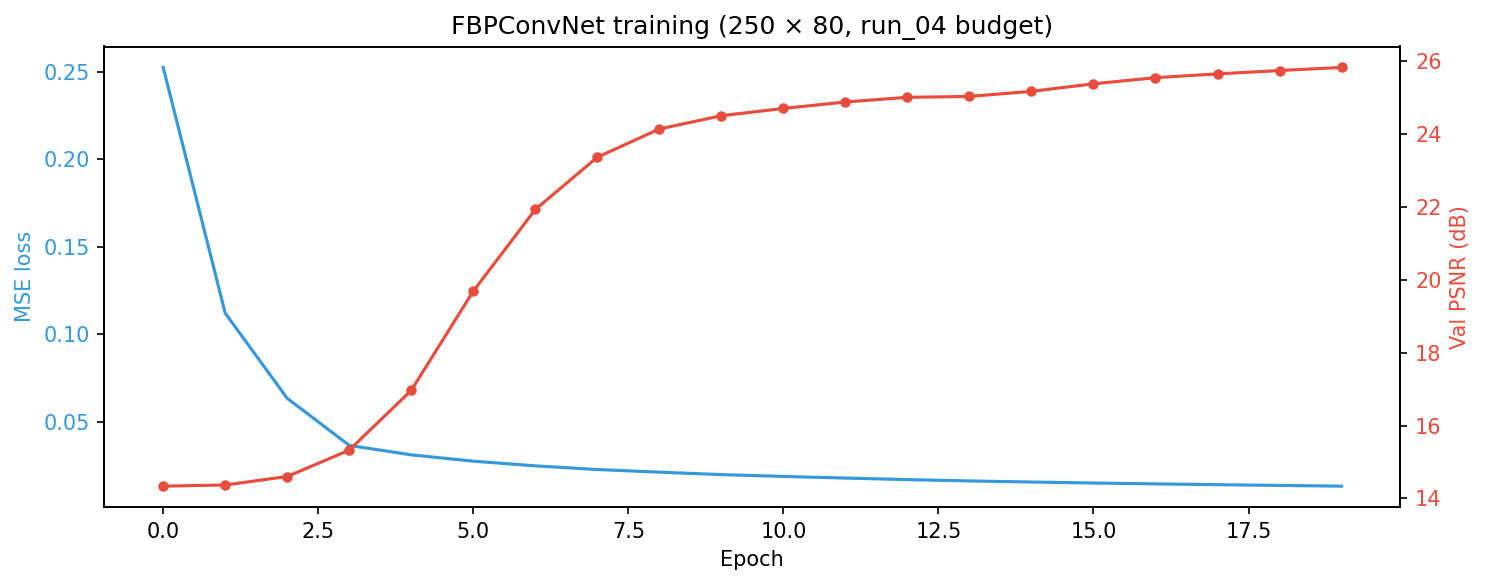

In [ ]:
# Training curves
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(train_losses, color='#3498db', label='Train loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('MSE loss', color='#3498db')
ax1.tick_params(axis='y', labelcolor='#3498db')

ax2 = ax1.twinx()
ax2.plot(val_psnrs, color='#e74c3c', marker='o', ms=4, label='Val PSNR')
ax2.set_ylabel('Val PSNR (dB)', color='#e74c3c')
ax2.tick_params(axis='y', labelcolor='#e74c3c')

plt.title('FBPConvNet training (250 × 80, run_04 budget)', fontsize=12)
plt.tight_layout()
plt.savefig(output_dir / "04_training_curves.pdf", bbox_inches="tight")
plt.show()

### Load trained checkpoint and verify on dev image

Loaded epoch 20, val PSNR 25.83 dB


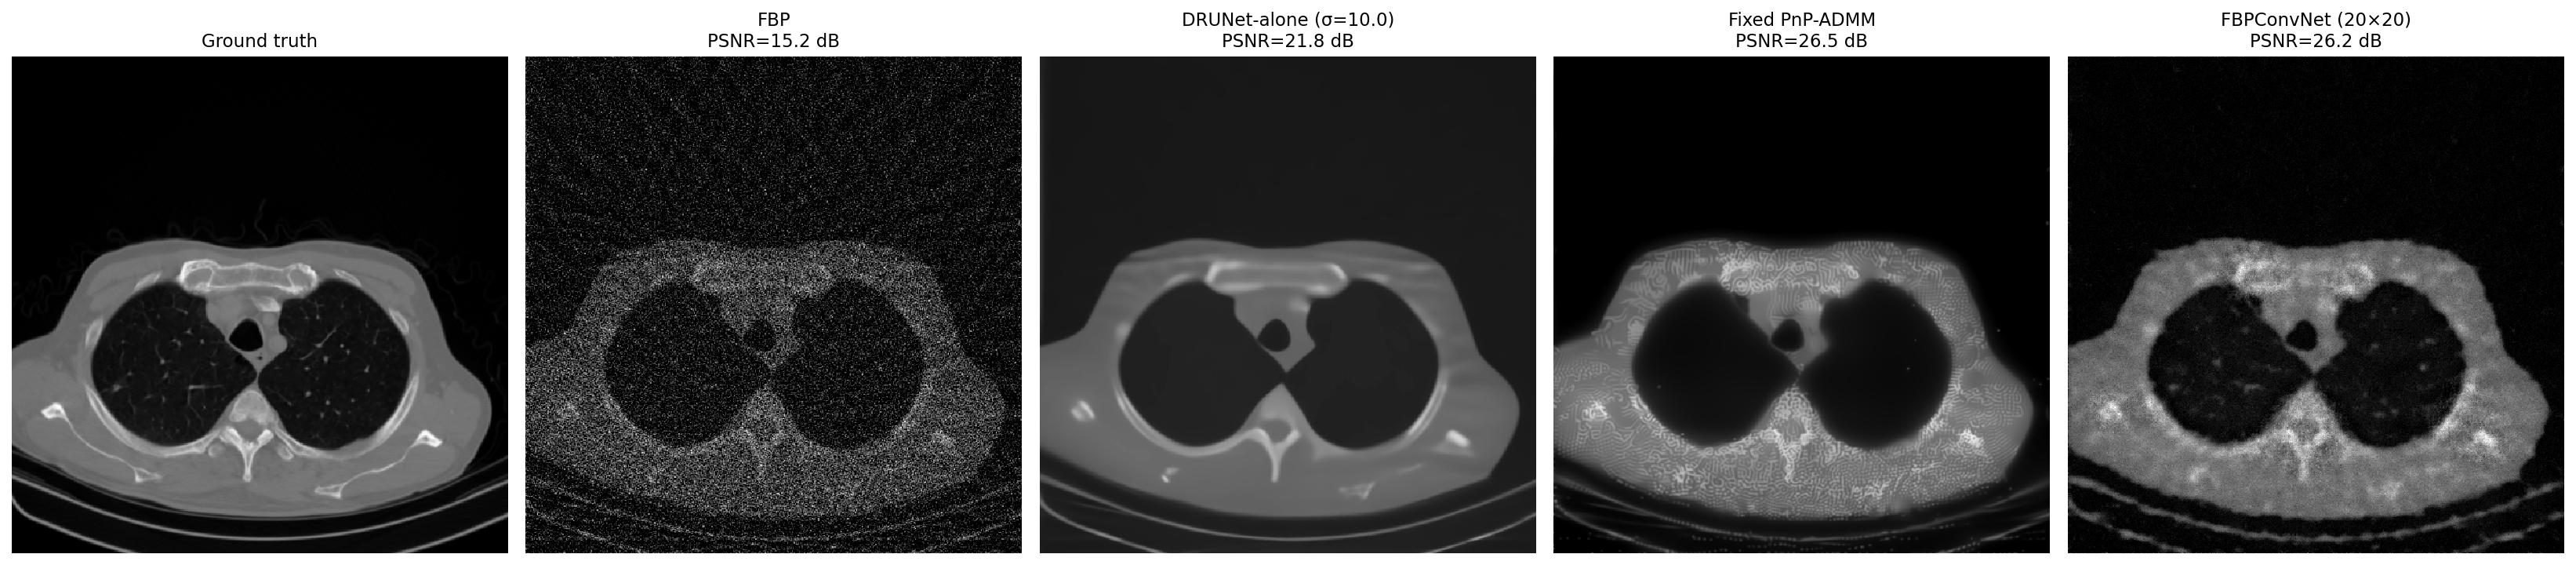

In [ ]:
ckpt_path = SAVE_DIR / "checkpoint_best_val.pth"
ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
print(f"Loaded epoch {ckpt['epoch']}, val PSNR {ckpt['val_psnr']:.2f} dB")

fbpconv_eval = FBPConvNetImage(model_parameters=model_params, geometry_parameters=geo).to(device)
fbpconv_eval.load_state_dict(ckpt['model_state_dict'])
fbpconv_eval.eval()

with torch.no_grad():
    x_fbpconv = fbpconv_eval(to_4d(x_fbp))[0]
x_fbpconv = ls_scale(gt, x_fbpconv).clamp(min=0)
fbpconv_psnr = psnr(gt, x_fbpconv)

# 5-panel: GT / FBP / DRUNet-alone / Fixed PnP / FBPConvNet
fig, axes = plt.subplots(1, 5, figsize=(22, 5))
panels = [
    (gt_np, "Ground truth"),
    (x_fbp[0].cpu().numpy(), f"FBP\nPSNR={fbp_psnr:.1f} dB"),
    (x_drunet[0].cpu().numpy(), f"DRUNet-alone (σ={DRUNET_ALONE_SIGMA})\nPSNR={drunet_psnr:.1f} dB"),
    (x_fix[0].cpu().numpy(), f"Fixed PnP-ADMM\nPSNR={fix_psnr:.1f} dB"),
    (x_fbpconv[0].cpu().numpy(), f"FBPConvNet ({N_TRAIN}×{N_EPOCHS})\nPSNR={fbpconv_psnr:.1f} dB"),
]
for ax, (img, title) in zip(axes, panels):
    ax.imshow(img, vmin=vmin, vmax=vmax, cmap='gray')
    ax.set_title(title, fontsize=11)
    ax.axis('off')
    
plt.tight_layout()
plt.savefig(output_dir / "05_comparisons.pdf", bbox_inches="tight")
plt.show()

### Moving to the package

Two pieces to migrate once the above works end-to-end:

1. **`scripts/train_fbpconvnet.py`** — promote cells 21–25 into a clean
   training script following the same arg-parsing pattern as
   `train_tfpnp.py`. Same arguments: `--n_train`, `--n_epochs`, `--lr`,
   `--output_dir`. The training loop body is the working version from cell 25.

2. **`evaluate_run.py`** — add `'FBPConvNet'` to `METHODS`, load the
   checkpoint at the top of `main()`, and add a new branch in
   `run_evaluation()`:

```python
   # FBPConvNet
   with torch.no_grad():
       x_fbpconv = fbpconv_model(to_4d(x_fbp))[0]
   x_fbpconv = ls_scale(gt, x_fbpconv).clamp(min=0)
   all_results[noise_frac]['FBPConvNet'].append(compute_metrics(gt, x_fbpconv))
```

3. **`evaluate_run.py` again** — add `'DRUNet'` the same way (using the
   inline `drunet_alone` function pattern from section 2).

Both baselines get colours and labels in `METHODS`, `METHOD_LABELS`, `COLORS`.

## 4. Summary

| Baseline | Trained? | Code in package? | Migration |
|---|---|---|---|
| DRUNet-alone | No (pretrained KAIR) | `DRUNetDenoiser` ✓ | Add method branch to `evaluate_run.py` |
| FBPConvNet | Yes (250 × 80) | LION's `FBPConvNet` ✓ | New `train_fbpconvnet.py` + method branch in `evaluate_run.py` |

Once migrated, NB10's main comparison table gains two columns:
6 methods total — FBP, TV, DRUNet-alone, FBPConvNet, Fixed PnP-ADMM, TFPnP.

The story they support:
- **DRUNet-alone** demonstrates the iterative coupling matters
  (if Fixed PnP-ADMM > DRUNet-alone by a clear margin)
- **FBPConvNet** shows what pure supervised learning achieves on the
  same data budget, putting TFPnP's RL approach in context.